# Description

It explores the context/tissue/cell type of the top samples associated with an LV.

Follow the notebook instructions below.

# Modules

In [1]:
import re
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from data.recount2 import LVAnalysis
from utils import chunker
import conf

# Settings

Specify below the LV id you are interested in:

In [2]:
LV_NAME = "LV946"

# Paths

These are paths to folder and files where we'll save our figures.

In [3]:
OUTPUT_FIGURES_DIR = Path(conf.RESULTS_DIR, "demo", f"{LV_NAME.lower()}").resolve()
display(OUTPUT_FIGURES_DIR)
OUTPUT_FIGURES_DIR.mkdir(parents=True, exist_ok=True)

PosixPath('/opt/data/results/demo/lv946')

In [4]:
OUTPUT_CELL_TYPE_FILEPATH = OUTPUT_FIGURES_DIR / f"{LV_NAME.lower()}-cell_types.svg"
display(OUTPUT_CELL_TYPE_FILEPATH)

PosixPath('/opt/data/results/demo/lv946/lv946-cell_types.svg')

# Load MultiPLIER summary

In [5]:
multiplier_model_summary = pd.read_pickle(conf.MULTIPLIER["MODEL_SUMMARY_FILE"])

In [6]:
multiplier_model_summary.shape

(2157, 5)

In [7]:
multiplier_model_summary.head()

,pathway,LV index,AUC,p-value,FDR
1,KEGG_LYSINE_DEGRADATION,1,0.388059,0.866078,0.956005
2,REACTOME_MRNA_SPLICING,1,0.733057,0.000048,0.000582
3,MIPS_NOP56P_ASSOCIATED_PRE_RRNA_COMPLEX,1,0.680555,0.001628,0.011366
4,KEGG_DNA_REPLICATION,1,0.549473,0.312155,0.539951
5,PID_MYC_ACTIVPATHWAY,1,0.639303,0.021702,0.083739


# Load LV data

You can use the `LVAnalysis` class to explore an LV.

In [8]:
lv_obj = LVAnalysis(LV_NAME)

Here I show the top 20 genes for our LV. You can see gene symbols, the LV weight (in column `LV603`) and the cytoband.

In [9]:
lv_obj.lv_genes.head(20)

,gene_name,LV946,gene_band
0,YPEL1,5.364993,22q11.22
1,PPIL2,4.463673,22q11.21
2,ZNF382,2.904596,19q13.12
3,ZNF605,2.832557,12q24.33
4,THRB,1.690380,3p24.2
5,OSBPL10,1.590576,3p22.3
6,G6PD,1.437346,NaN
7,ELMO2,1.361695,20q13.12
8,RCHY1,1.311294,4q21.1
9,TAB2,1.276097,6q25.1


Show the pathways our LV is aligned to (neutrophils):

In [10]:
multiplier_model_summary[
    multiplier_model_summary["LV index"].isin((LV_NAME[2:],))
    & (
        (multiplier_model_summary["FDR"] < 0.05)
        & (multiplier_model_summary["AUC"] >= 0.75)
    )
]

[2025-09-26 17:27:38,482 - numexpr.utils] INFO: Note: NumExpr detected 48 cores but "NUMEXPR_MAX_THREADS" not set, so enforcing safe limit of 8.
[2025-09-26 17:27:38,483 - numexpr.utils] INFO: NumExpr defaulting to 8 threads.


,pathway,LV index,AUC,p-value,FDR


Here I load the LV metadata.
This is, for each sample from our matrix B, we load its metadata.
The `LVAnalysis` class takes care of downloading all necessary files from recount2.

In [11]:
lv_data = lv_obj.get_experiments_data()

SRP057196, SRP055569, SRP066834, SRP060416, SRP033135, SRP059379, SRP007947, SRP042161, SRP058773, SRP050499, SRP022892, SRP007338, SRP013363, SRP063840, SRP009247, SRP007461, SRP056957, SRP008218, SRP064464, SRP055440, SRP059266, SRP030628, SRP013825, SRP033248, SRP049479, SRP022259, SRP055153, 

/opt/code/libs/data/recount2.py:323: UserWarning: Not all experiments data could be loaded (26 != 27)
  warnings.warn(


In [12]:
lv_data.shape

(4699, 52)

In [13]:
lv_data.head()

tissue        cell type               age c1 chip id  \
project   run                                                                
SRP057196 SRR1975007  cortex  fetal_quiescent  prenatal 16-18 W  nochipID4   
          SRR1975008  cortex  fetal_quiescent  prenatal 16-18 W  nochipID4   
          SRR1975006  cortex  fetal_quiescent  prenatal 16-18 W  nochipID4   
          SRR1975005  cortex  fetal_quiescent  prenatal 16-18 W  nochipID4   
          SRR1975004  cortex  fetal_quiescent  prenatal 16-18 W  nochipID4   

                     experiment_sample_name Stage tonsil donor facs gating  \
project   run                                                                
SRP057196 SRR1975007                  FB_S6   NaN          NaN         NaN   
          SRR1975008                  FB_S6   NaN          NaN         NaN   
          SRR1975006                  FB_S6   NaN          NaN         NaN   
          SRR1975005                  FB_S6   NaN          NaN         NaN   
          SRR1975004                  FB_S6   NaN          NaN         NaN   

                     hour post serum-switch debris  ... genotype  Sex  \
project   run                                       ...                 
SRP057196 SRR1975007                    NaN    NaN  ...      NaN  NaN   
          SRR1975008                    NaN    NaN  ...      NaN  NaN   
          SRR1975006                    NaN    NaN  ...      NaN  NaN   
          SRR1975005                    NaN    NaN  ...      NaN  NaN   
          SRR1975004                    NaN    NaN  ...      NaN  NaN   

                     age (year) age (day) germinal zone survival  \
project   run                                                      
SRP057196 SRR1975007        NaN       NaN           NaN      NaN   
          SRR1975008        NaN       NaN           NaN      NaN   
          SRR1975006        NaN       NaN           NaN      NaN   
          SRR1975005        NaN       NaN           NaN      NaN   
          SRR1975004        NaN       NaN           NaN      NaN   

                     disease state sample type treatment     LV946  
project   run                                                       
SRP057196 SRR1975007           NaN         NaN       NaN  0.403596  
          SRR1975008           NaN         NaN       NaN -0.091957  
          SRR1975006           NaN         NaN       NaN -0.097748  
          SRR1975005           NaN         NaN       NaN -0.015001  
          SRR1975004           NaN         NaN       NaN -0.064476  

[5 rows x 52 columns]

# LV cell types analysis

## Get top attributes

Here I quickly show the top attributes in our metadata for which we have the largest LV variance.
This is just to have an idea of the variance across different attributes

In [14]:
lv_attrs = lv_obj.get_attributes_variation_score()
display(lv_attrs.head(20))

c1 chip id                        0.056749
experiment_sample_name            0.056749
age                               0.054207
tissue                            0.032166
antibody                          0.028988
Stage                             0.021046
iPSc                              0.020874
reprogramming vector              0.020874
time                              0.020874
cell type                         0.015639
culture medium                    0.009919
tonsil donor                      0.009165
facs gating                       0.009165
cell line stably expressing       0.006778
par-clip antibody                 0.006778
read length                       0.005480
library type                      0.005480
cancer or normal                  0.005179
well number                       0.005049
reprogramming time point (day)    0.005049
dtype: float64

Since we are interested in cell types and tissues, the code below will find which attributes contain "cell type" or "tissue", so we can select from these results.

In [16]:
# show those with cell type or tissue in their name
_tmp = pd.Series(lv_attrs.index)
_tmp2 = lv_attrs[
    _tmp.str.match(
        "(?:cell.*(type|line)$)|(?:tissue$)|(?:tissue.*type$)",
        case=False,
        flags=re.IGNORECASE,
    ).values
].sort_values(ascending=False)
display(_tmp2)

tissue       0.032166
cell type    0.015639
cell line    0.002997
dtype: float64

Select from the output above those you are interested in. Usually all of them.

In [21]:
lv_attrs_selected = _tmp2.index.tolist()
display(lv_attrs_selected)

['tissue', 'cell type', 'cell line']

In [22]:
# lv_attrs_selected = [
#     "cell type",
#     "tissue",
#     "tissue subtype",
#     "cell line",
# ]

In [23]:
_tmp = lv_data.loc[
    :,
    lv_attrs_selected + [LV_NAME],
]

In [24]:
_tmp_seq = list(chunker(_tmp.sort_values(LV_NAME, ascending=False), 25))

Now that we selected attributes that might be providing information about the cell type, we can see which are the top ones.

If you change the number in the cell below, you can paginate over the entire set of results; for example, with `_tmp_seq[1]` you'll see the next "page" in a descending order with respect to the LV value. So the ones at the top are the most important ones.

In [25]:
_tmp_seq[0]

tissue  \
project   run                                                             
SRP057196 SRR1974934                                             cortex   
SRP055569 SRR2019217                                                NaN   
SRP066834 SRR2967794                                    Fetal neocortex   
SRP060416 SRR2088145                                                NaN   
SRP066834 SRR2967480  Microdissected cortical-like ventricle from ce...   
          SRR2967769                                    Fetal neocortex   
SRP033135 SRR1033274                                                NaN   
SRP066834 SRR2967639                                    Fetal neocortex   
          SRR2967733                                    Fetal neocortex   
          SRR2967735                                    Fetal neocortex   
SRP057196 SRR1974993                                             cortex   
SRP066834 SRR2967830                                    Fetal neocortex   
          SRR2967826                                    Fetal neocortex   
SRP057196 SRR1974962                                             cortex   
SRP066834 SRR2967753                                    Fetal neocortex   
SRP060416 SRR2088078                                                NaN   
SRP066834 SRR2967407                Dissociated whole cerebral organoid   
          SRR2967783                                    Fetal neocortex   
SRP057196 SRR1974987                                             cortex   
          SRR1974675                                             cortex   
SRP066834 SRR2967703                                    Fetal neocortex   
SRP057196 SRR1974929                                             cortex   
SRP066834 SRR2967818                                    Fetal neocortex   
          SRR2967832                                    Fetal neocortex   
SRP057196 SRR1974939                                             cortex   

                                                              cell type  \
project   run                                                             
SRP057196 SRR1974934                                    fetal_quiescent   
SRP055569 SRR2019217  mixture of U87 human glioma cells and WI-38 hu...   
SRP066834 SRR2967794                                                NaN   
SRP060416 SRR2088145                       tonsil Innate lymphoid cells   
SRP066834 SRR2967480                                                NaN   
          SRR2967769                                                NaN   
SRP033135 SRR1033274             Human Skeletal Muscle Myoblasts (HSMM)   
SRP066834 SRR2967639                                                NaN   
          SRR2967733                                                NaN   
          SRR2967735                                                NaN   
SRP057196 SRR1974993                                    fetal_quiescent   
SRP066834 SRR2967830                                                NaN   
          SRR2967826                                                NaN   
SRP057196 SRR1974962                                    fetal_quiescent   
SRP066834 SRR2967753                                                NaN   
SRP060416 SRR2088078                       tonsil Innate lymphoid cells   
SRP066834 SRR2967407                                                NaN   
          SRR2967783                                                NaN   
SRP057196 SRR1974987                                    fetal_quiescent   
          SRR1974675                                    fetal_quiescent   
SRP066834 SRR2967703                                                NaN   
SRP057196 SRR1974929                                    fetal_quiescent   
SRP066834 SRR2967818                                                NaN   
          SRR2967832                                                NaN   
SRP057196 SRR1974939                                    fetal_quiescent   

             

You can see above that the RNA-seq samples are from neutrophils or granulocytes.
If we move to the next "page", we'll see this:

In [26]:
_tmp_seq[1]

,,tissue,cell type,cell line,LV946
project,run,,,,
SRP057196,SRR1974922,cortex,fetal_quiescent,NaN,0.449472
SRP066834,SRR2967807,Fetal neocortex,NaN,NaN,0.445207
SRP057196,SRR1974762,cortex,neurons,NaN,0.442501
SRP066834,SRR2967722,Fetal neocortex,NaN,NaN,0.442162
SRP057196,SRR1974734,cortex,astrocytes,NaN,0.436507
SRP066834,SRR2967708,Fetal neocortex,NaN,NaN,0.433165
SRP059379,SRR2060565,NaN,iPSC-derived cortical neuron,NaN,0.432593
SRP055569,SRR2018995,NaN,U87 human glioma cells,NaN,0.419106
SRP066834,SRR2967809,Fetal neocortex,NaN,NaN,0.417320


Although the attributes we selected (`cell type`, `celltype` and `tissue`) seem to be enough for most of the RNA-seq samples to get their cell types, this is not the case for some of them. For example, we have empty values (NaN) for `SRP015360`.

You can explore the metadata provided for a particular SPR with the code below. Let's see what we have in `SRP015360`:

In [27]:
# list the top 10 samples from this project
lv_data.loc[["SRP039591"]].dropna(how="all", axis=1).sort_values(
    LV_NAME, ascending=False
).head(10)

KeyError: "['SRP039591'] not in index"

So for `SRP015360` we only have three attributes: `age`, `Sex` and `treatment`. No cell type information. Here you can start grasping the challenges in analyzing this data.

If you are really interested in this metadata for this project, you can use this URL:
```
https://trace.ncbi.nlm.nih.gov/Traces/sra/?study=SRP015360
```
where you can put the SRP code you want. If you check the URL above, you'll see that these samples were taken from neutrophils as well (treated with different stimuli), although we don't have metadata about the cell type/tissue.

Ok, we do not want several attributes conveying the same information (cell types), just a single one, so here we'll combine the attributes we found before with a particular _order_.
In this case I select `cell type` _first_ (the order is important), `celltype` as second, and `tissue` as third/last.
This means that I will use the information in `cell type` first, but if this is empty (as in `SRP045500`), we'll try with `celltype`, and so on.

In [28]:
SELECTED_ATTRIBUTES = lv_attrs_selected

In [29]:
# SELECTED_ATTRIBUTES = [
#     "cell type",
#     "tissue",
#     "tissue subtype",
#     "cell line",
# ]

In [30]:
display(SELECTED_ATTRIBUTES)

['tissue', 'cell type', 'cell line']

## Get a single attribute with "cell type/tissue" information

In [31]:
plot_data = lv_data.loc[:, SELECTED_ATTRIBUTES + [LV_NAME]]

In [32]:
# if blank/nan, fill cell type column with tissue content
_new_column = plot_data[SELECTED_ATTRIBUTES].fillna(method="backfill", axis=1)[
    SELECTED_ATTRIBUTES[0]
]
plot_data[SELECTED_ATTRIBUTES[0]] = _new_column
plot_data = plot_data.drop(columns=SELECTED_ATTRIBUTES[1:])
plot_data = plot_data.fillna({SELECTED_ATTRIBUTES[0]: "NOT CATEGORIZED"})

In [33]:
plot_data = plot_data.sort_values(LV_NAME, ascending=False)

In [34]:
plot_data.head(20)

tissue  \
project   run                                                             
SRP057196 SRR1974934                                             cortex   
SRP055569 SRR2019217  mixture of U87 human glioma cells and WI-38 hu...   
SRP066834 SRR2967794                                    Fetal neocortex   
SRP060416 SRR2088145                       tonsil Innate lymphoid cells   
SRP066834 SRR2967480  Microdissected cortical-like ventricle from ce...   
          SRR2967769                                    Fetal neocortex   
SRP033135 SRR1033274             Human Skeletal Muscle Myoblasts (HSMM)   
SRP066834 SRR2967639                                    Fetal neocortex   
          SRR2967733                                    Fetal neocortex   
          SRR2967735                                    Fetal neocortex   
SRP057196 SRR1974993                                             cortex   
SRP066834 SRR2967830                                    Fetal neocortex   
          SRR2967826                                    Fetal neocortex   
SRP057196 SRR1974962                                             cortex   
SRP066834 SRR2967753                                    Fetal neocortex   
SRP060416 SRR2088078                       tonsil Innate lymphoid cells   
SRP066834 SRR2967407                Dissociated whole cerebral organoid   
          SRR2967783                                    Fetal neocortex   
SRP057196 SRR1974987                                             cortex   
          SRR1974675                                             cortex   

                         LV946  
project   run                   
SRP057196 SRR1974934  4.471576  
SRP055569 SRR2019217  3.325562  
SRP066834 SRR2967794  1.722204  
SRP060416 SRR2088145  1.285178  
SRP066834 SRR2967480  1.225767  
          SRR2967769  0.931232  
SRP033135 SRR1033274  0.922274  
SRP066834 SRR2967639  0.839613  
          SRR2967733  0.745102  
          SRR2967735  0.743153  
SRP057196 SRR1974993  0.627049  
SRP066834 SRR2967830  0.624974  
          SRR2967826  0.619550  
SRP057196 SRR1974962  0.591080  
SRP066834 SRR2967753  0.580240  
SRP060416 SRR2088078  0.555685  
SRP066834 SRR2967407  0.530200  
          SRR2967783  0.513838  
SRP057196 SRR1974987  0.511998  
          SRR1974675  0.480538

You can see that now all attributes ("celltype", "cell type" and "tissue") are combined under a single attribute named "cell type".
For example, if you look at `SRP045500`, which had a value under "celltype" but an empty (NaN) value for attribute "cell type", that now the value was moved to "cell type" (it was unified into this single attribute).

If you see "NOT CATEGORIZED", it means that none of the attributes you used had a value (they were all empty or NaN). In this case you would go the URL before and read the article/RNA-seq data description to find out the cell type or tissue (or whatever attribute your are interested in).

## Standardize cell type names

When cell type values are different but represent the same cell type, we unify them:

In [35]:
final_plot_data = plot_data.replace(
    {
        SELECTED_ATTRIBUTES[0]: {
            # # neutrophils:
            # "primary human neutrophils": "Neutrophils",
            # "Neutrophil isolated from peripheral blood": "Neutrophils",
            # "Neutrophil": "Neutrophils",
            # "neutrophils (Neu)": "Neutrophils",
            # # granulocytes:
            # "granulocyte": "Granulocytes",
            # # monocytes:
            # "primary human monocytes": "Monocytes",
            # # whole blood:
            # #             "whole blood": "Whole blood",  # uncomment this line to merge occurences of "whole blood" into "Whole blood"
            # "Whole Blood": "Whole blood",
            # # PBMC:
            # "primary human PBMC": "PBMC",
            # # B-cells:
            # "primary human B cells": "B cells",
            # # T-cells:
            # "primary human T cells": "T cells",
            # # epithelial cells:
            # "epithelial cells (Epi)": "Epithelial cells",
            # "primary human myeloid DC": "mDCs",
        }
    }
)

The code below is more advanced, but you can use it to customize even further your final attribute value (for example, if you want to use the cell type, but put the treatment name with parenthesis).

In [36]:
# # add also tissue information to these projects
# _srp_code = "SRP061881"
# _tmp = final_plot_data.loc[(_srp_code,)].apply(
#     lambda x: lv_data.loc[(_srp_code, x.name), "cell type"]
#     + f" ({lv_data.loc[(_srp_code, x.name), 'tissue']})",
#     axis=1,
# )
# final_plot_data.loc[(_srp_code, _tmp.index), SELECTED_ATTRIBUTES[0]] = _tmp.values

In [37]:
# # all samples from SRP015360 are neutrophils
# final_plot_data[SELECTED_ATTRIBUTES[0]] = final_plot_data.apply(
#     lambda x: "Neutrophils" if x.name[0] in ("SRP015360",) else x[SELECTED_ATTRIBUTES[0]],
#     axis=1,
# )

In [38]:
final_plot_data = final_plot_data.sort_values(LV_NAME, ascending=False)

## Threshold LV values

The code below is useful in case you want to put a threshold to the plot (for example, you have same samples with very high values).

In [39]:
# final_plot_data.loc[
#     final_plot_data[LV_NAME] > LV_AXIS_THRESHOLD, LV_NAME
# ] = LV_AXIS_THRESHOLD

## Delete samples with no tissue/cell type information

If you are not interested in samples for which we couldn't find cell type/tissue information, you can delete them by uncommenting the code below.
However, if you want, you can take a look at those later (we'll show you how at the end).

In [40]:
# final_plot_data = final_plot_data[
#     final_plot_data[SELECTED_ATTRIBUTE] != "NOT CATEGORIZED"
# ]

## Set top cell types to show

In [41]:
N_TOP_ATTRS = 10

In [42]:
attr_order = (
    final_plot_data.groupby(SELECTED_ATTRIBUTES[0])
    .max()
    .sort_values(LV_NAME, ascending=False)
    .index[:N_TOP_ATTRS]
    .tolist()
)

In [43]:
len(attr_order)

10

In [44]:
attr_order[:5]

['cortex',
 'mixture of U87 human glioma cells and WI-38 human lung fibroblast cells',
 'Fetal neocortex',
 'tonsil Innate lymphoid cells',
 'Microdissected cortical-like ventricle from cerebral organoid']

# Plot

Now we create the plot with RNA-seq samples as points, cell types in the x-axis, and the LV value in the y-axis.
This shows you in which cell types genes in LV603 are primirily expressed.

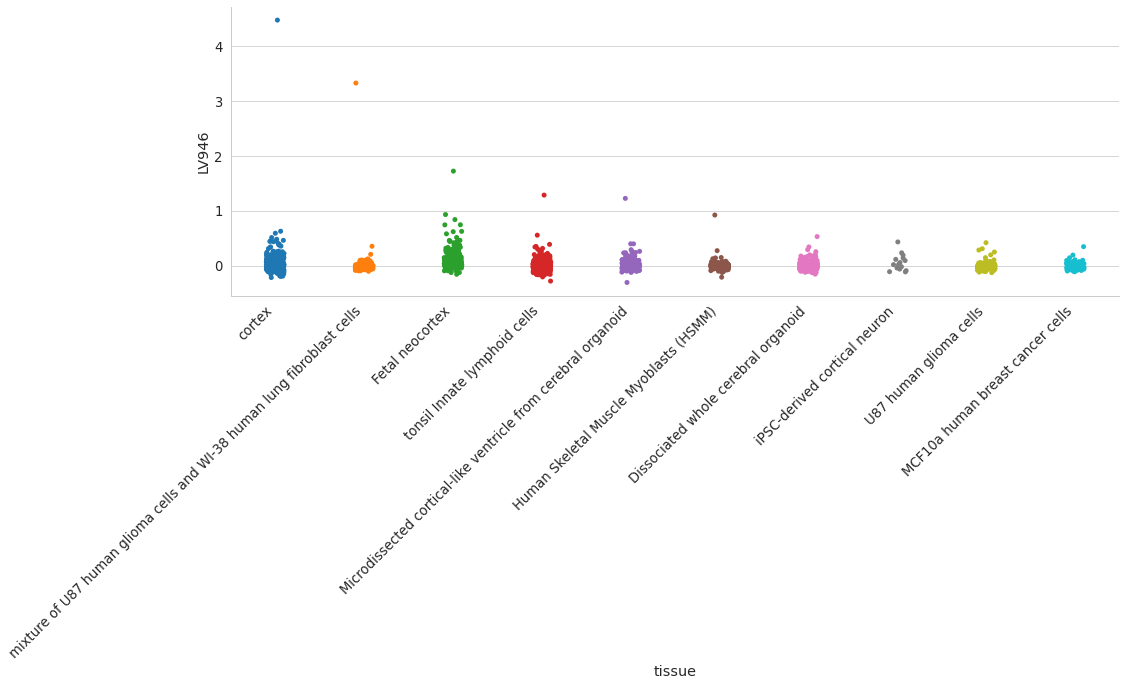

In [45]:
with sns.plotting_context("paper", font_scale=1.5), sns.axes_style("whitegrid"):
    sns.catplot(
        data=final_plot_data,
        y=LV_NAME,
        x=SELECTED_ATTRIBUTES[0],
        order=attr_order,
        kind="strip",
        height=5,
        aspect=3,
    )
    plt.xticks(rotation=45, horizontalalignment="right")

    # You can save the figure if you uncomment the code below
    # the figure will be created under ${DATA_FOLDER}/results/demo

    plt.savefig(
        OUTPUT_CELL_TYPE_FILEPATH,
        bbox_inches="tight",
        facecolor="white",
    )

# Debug

Now that you have the figure for your LV, you can debug some things.
For example, you'll see above that some samples are "NOT CATEGORIZED".
Let's see which are those:

In [46]:
with pd.option_context(
    "display.max_rows", None, "display.max_columns", None, "display.max_colwidth", None
):
    _tmp = final_plot_data[
        final_plot_data[SELECTED_ATTRIBUTES[0]].str.contains("cortex")
    ]
    display(_tmp.head(20))

tissue     LV946
project   run                                  
SRP057196 SRR1974934           cortex  4.471576
SRP066834 SRR2967794  Fetal neocortex  1.722204
          SRR2967769  Fetal neocortex  0.931232
          SRR2967639  Fetal neocortex  0.839613
          SRR2967733  Fetal neocortex  0.745102
          SRR2967735  Fetal neocortex  0.743153
SRP057196 SRR1974993           cortex  0.627049
SRP066834 SRR2967830  Fetal neocortex  0.624974
          SRR2967826  Fetal neocortex  0.619550
SRP057196 SRR1974962           cortex  0.591080
SRP066834 SRR2967753  Fetal neocortex  0.580240
          SRR2967783  Fetal neocortex  0.513838
SRP057196 SRR1974987           cortex  0.511998
          SRR1974675           cortex  0.480538
SRP066834 SRR2967703  Fetal neocortex  0.461761
SRP057196 SRR1974929           cortex  0.461443
SRP066834 SRR2967818  Fetal neocortex  0.459884
          SRR2967832  Fetal neocortex  0.454680
SRP057196 SRR1974939           cortex  0.451741
          SRR1974922           cortex  0.449472

We don't have information about cell type/tissue for these.
But we can manually go to the URL showed before and check out.
For example, for `SRP015360` we can open our browser with this URL:
https://trace.ncbi.nlm.nih.gov/Traces/sra/?study=SRP012461, and see that the samples were taken from neutrophils.

If you need to see which information is provided by each SRP, you can again use the code below:

In [48]:
# what is there in these projects?
lv_data.loc[["SRP066834"]].dropna(how="all", axis=1).sort_values(
    LV_NAME, ascending=False
).head(60)

tissue  \
project   run                                                             
SRP066834 SRR2967794                                    Fetal neocortex   
          SRR2967480  Microdissected cortical-like ventricle from ce...   
          SRR2967769                                    Fetal neocortex   
          SRR2967639                                    Fetal neocortex   
          SRR2967733                                    Fetal neocortex   
          SRR2967735                                    Fetal neocortex   
          SRR2967830                                    Fetal neocortex   
          SRR2967826                                    Fetal neocortex   
          SRR2967753                                    Fetal neocortex   
          SRR2967407                Dissociated whole cerebral organoid   
          SRR2967783                                    Fetal neocortex   
          SRR2967703                                    Fetal neocortex   
          SRR2967818                                    Fetal neocortex   
          SRR2967832                                    Fetal neocortex   
          SRR2967807                                    Fetal neocortex   
          SRR2967722                                    Fetal neocortex   
          SRR2967708                                    Fetal neocortex   
          SRR2967809                                    Fetal neocortex   
          SRR2967594  Microdissected cortical-like ventricle from ce...   
          SRR2967506  Microdissected cortical-like ventricle from ce...   
          SRR2967754                                    Fetal neocortex   
          SRR2967645                                    Fetal neocortex   
          SRR2967628                                    Fetal neocortex   
          SRR2967393                Dissociated whole cerebral organoid   
          SRR2967823                                    Fetal neocortex   
          SRR2967791                                    Fetal neocortex   
          SRR2967790                                    Fetal neocortex   
          SRR2967643                                    Fetal neocortex   
          SRR2967672                                    Fetal neocortex   
          SRR2967637                                    Fetal neocortex   
          SRR2967636                                    Fetal neocortex   
          SRR2967812                                    Fetal neocortex   
          SRR2967731                                    Fetal neocortex   
          SRR2967779                                    Fetal neocortex   
          SRR2967332                Dissociated whole cerebral organoid   
          SRR2967584  Microdissected cortical-like ventricle from ce...   
          SRR2967622                                    Fetal neocortex   
          SRR2967757                                    Fetal neocortex   
          SRR2967772                                    Fetal neocortex   
          SRR2967635                                    Fetal neocortex   
          SRR2967696                                    Fetal neocortex   
          SRR2967693                                    Fetal neocortex   
          SRR2967799                                    Fetal neocortex   
          SRR2967511  Microdissected cortical-like ventricle from ce...   
          SRR2967581  Microdissected cortical-like ventricle from ce...   
          SRR2967784                                    Fetal neocortex   
          SRR2967359                Dissociated whole cerebral organoid   
          SRR2967737                                    Fetal neocortex   
          SRR2967730                                    Fetal neocortex   
          SRR2967482  Microdissected cortical-like ventricle from ce...   
          SRR2967629                                    Fetal neocortex   
          SRR2967612                                    Fetal neocortex   
          SRR29

Now you can go back to section `Standardize cell type names` in this notebook and adjust according to this findings to improve the figure.
Once you are happy, you can remove the `NOT CATEGORIZED` items by uncommenting the code in `Delete samples with no tissue/cell type information`.